# 09 - Business insights & prediction

Usa el modelo final (`08_final_model.ipynb`) para puntuar a los clientes `Joined` (sin
desenlace conocido), los segmenta en tiers de riesgo, y deja una tabla lista para el
dashboard de Power BI.

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"

final = joblib.load(f"{MODELS_DIR}/final_model.joblib")
model, threshold, model_name = final["model"], final["threshold"], final["model_name"]

joined_encoded = pd.read_parquet(f"{PROCESSED_DIR}/joined_encoded.parquet")
X_joined = joined_encoded.drop(columns=["Customer_ID"])

print(f"Modelo final: {model_name} (threshold={threshold:.3f})")
print(f"Clientes Joined a puntuar: {X_joined.shape[0]}")

Modelo final: logistic_regression (threshold=0.255)
Clientes Joined a puntuar: 405


## Puntuar y segmentar en tiers de riesgo

In [2]:
churn_risk_score = model.predict_proba(X_joined)[:, 1]

# Los tiers estan atados al umbral operativo (`threshold`, elegido en 08 por recall con
# precision >= 0.55) en vez de cortes fijos independientes. Antes, High/Medium/Low usaban
# 0.80/0.60 sin relacion con el umbral de decision -- resultado: clientes que el modelo
# marcaba como churn (score >= threshold) podian caer en el tier "Low". Con esto, el tier
# nunca contradice al flag `predicted_churn`.
HIGH_RISK_CUTOFF = 0.60  # dentro de los predichos como churn, prioridad de contacto

def tier(score):
    if score >= HIGH_RISK_CUTOFF:
        return "High"
    if score >= threshold:
        return "Medium"
    return "Low"

df_joined_scored = pd.DataFrame({
    "Customer_ID": joined_encoded["Customer_ID"],
    "churn_risk_score": churn_risk_score,
    "risk_tier": [tier(s) for s in churn_risk_score],
    "predicted_churn": (churn_risk_score >= threshold).astype(int),
})

df_joined_scored["risk_tier"] = pd.Categorical(
    df_joined_scored["risk_tier"], categories=["Low", "Medium", "High"], ordered=True
)

print(df_joined_scored["churn_risk_score"].describe())
print()
print(df_joined_scored["risk_tier"].value_counts().sort_index())
print()
print(f"Predicted churners (score >= {threshold:.3f}): {df_joined_scored['predicted_churn'].sum()}")

count    405.000000
mean       0.418970
std        0.239822
min        0.004509
25%        0.200909
50%        0.395096
75%        0.615313
max        0.966253
Name: churn_risk_score, dtype: float64

risk_tier
Low       125
Medium    170
High      110
Name: count, dtype: int64

Predicted churners (score >= 0.255): 280


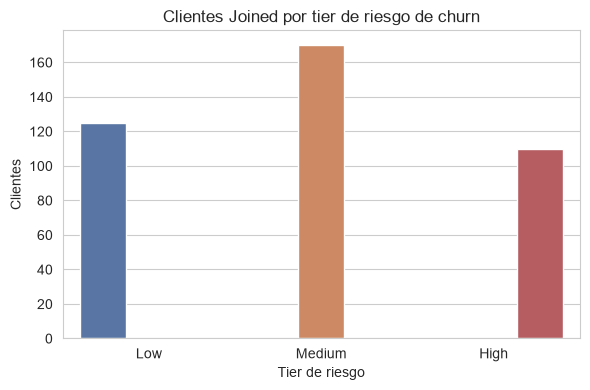

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_joined_scored, x="risk_tier", order=["Low", "Medium", "High"], hue="risk_tier", palette=["#4C72B0", "#DD8452", "#C44E52"], legend=False)
plt.title("Clientes Joined por tier de riesgo de churn")
plt.xlabel("Tier de riesgo")
plt.ylabel("Clientes")
plt.tight_layout()
plt.show()

## Importancia de variables del modelo final

Solo aplica a modelos basados en arboles (`feature_importances_`). Si el ganador fue
Logistic Regression, se usan los coeficientes absolutos como proxy de importancia en su
lugar (misma escala porque las features ya pasaron por `StandardScaler` en el pipeline).

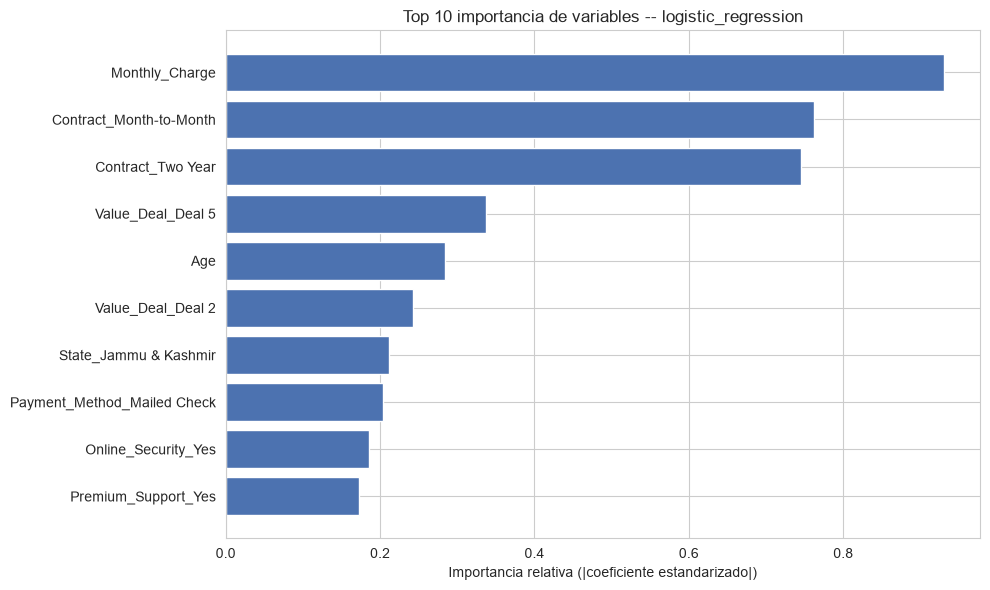

,feature,importance,signed_coefficient,rank
0,Monthly_Charge,0.930587,0.930587,1
1,Contract_Month-to-Month,0.761507,0.761507,2
2,Contract_Two Year,0.745168,-0.745168,3
3,Value_Deal_Deal 5,0.336550,0.336550,4
4,Age,0.284301,0.284301,5
5,Value_Deal_Deal 2,0.242499,-0.242499,6
6,State_Jammu & Kashmir,0.212156,0.212156,7
7,Payment_Method_Mailed Check,0.203489,0.203489,8
8,Online_Security_Yes,0.185267,-0.185267,9
9,Premium_Support_Yes,0.172512,-0.172512,10


In [4]:
estimator = model.named_steps["clf"] if hasattr(model, "named_steps") else model

if hasattr(estimator, "feature_importances_"):
    importance = pd.Series(estimator.feature_importances_, index=X_joined.columns)
    signed_coefficient = pd.Series(0.0, index=X_joined.columns)  # sin direccion en modelos de arbol
else:
    signed_coefficient = pd.Series(estimator.coef_[0], index=X_joined.columns)
    importance = signed_coefficient.abs()

df_feature_importance = pd.DataFrame({
    "feature": importance.index,
    "importance": importance.values,
    "signed_coefficient": signed_coefficient.loc[importance.index].values,
}).sort_values("importance", ascending=False).reset_index(drop=True)
df_feature_importance["rank"] = df_feature_importance.index + 1

plt.figure(figsize=(10, 6))
top10 = df_feature_importance.head(10)
plt.barh(top10["feature"][::-1], top10["importance"][::-1], color="#4C72B0")
plt.title(f"Top 10 importancia de variables -- {model_name}")
plt.xlabel("Importancia relativa (|coeficiente estandarizado|)")
plt.tight_layout()
plt.show()

df_feature_importance.head(10)

In [5]:
df_feature_importance.to_csv(f"{PROCESSED_DIR}/model_feature_importance.csv", index=False)
print("Guardado: model_feature_importance.csv")

Guardado: model_feature_importance.csv


## Guardar la tabla para el dashboard

In [6]:
df_joined_scored.to_csv(f"{PROCESSED_DIR}/joined_scored.csv", index=False)
print("Guardado: joined_scored.csv")
df_joined_scored.head()

Guardado: joined_scored.csv


,Customer_ID,churn_risk_score,risk_tier,predicted_churn
0,93520-GUJ,0.518241,Medium,1
1,57256-BIH,0.127368,Low,0
2,72357-MAD,0.631431,High,1
3,66612-KAR,0.151594,Low,0
4,22119-WES,0.131719,Low,0


## Conclusion

- El modelo final impreso arriba (`model_name`) se eligio en `07_model_evaluation.ipynb` por
  Recall de churn y se afino en `08_final_model.ipynb`; el umbral de decision impreso arriba
  tambien se eligio ahi para priorizar Recall sin destruir la Precision.
- `df_joined_scored` (`Customer_ID`, `churn_risk_score`, `risk_tier`, `predicted_churn`)
  queda persistido en `data/processed/joined_scored.csv` -- fuera del repo (regenerable desde
  `data/Customer_Data.csv` corriendo `04`-`09` en orden). Para usarlo en Power BI hace falta
  una tabla nueva en el pipeline dbt, fuera de `gold/` segun `docs/dbt-models.md` --
  ver `dbt/models/ml/`.
- Tiers atados al umbral operativo (no a cortes fijos independientes): `>= 0.60` High,
  `[threshold, 0.60)` Medium, `< threshold` Low. `predicted_churn = 1` exactamente cuando
  `churn_risk_score >= threshold` -- coincide siempre con tier High o Medium, nunca con Low.
- `df_feature_importance` (`feature`, `importance`, `signed_coefficient`, `rank`) queda en
  `data/processed/model_feature_importance.csv`. `signed_coefficient` distingue features que
  suben el riesgo (positivo) de las que lo bajan (negativo) -- `importance` sola no alcanza
  para esa lectura.